# Battery Current Time Series Model Evaluation

## Import Library

In [1]:
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from TimeSeries.src.preprocessing.preprocessing import get_datasets

2026-03-21 01:30:18.260044: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-21 01:30:18.306840: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-21 01:30:19.409420: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Load Test Data

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = get_datasets()

Loading:  /home/abel-putra/AndroidMonitoring/Clustering/data/dataset/dataset_time_series.csv
Data Shape:  (124313, 11)
Param Saved
Feature Scaled
Feature Shape:  (124253, 45, 9)
Label Shape:  (124253, 15)
Train Shape:  (74551, 45, 9)
Validation Shape:  (24851, 45, 9)
Test Shape:  (24851, 45, 9)


In [3]:
param_dir = "../data/param/params.json"
with open(param_dir) as f:
    params = json.load(f)

mean_feature = params["mean_feature"]
scale_feature = params["scale_feature"]
mean_target = params["mean_target"]
scale_target = params["scale_target"]
print("Mean Feature: ", mean_feature)
print("Scale Feature: ", scale_feature)
print("Mean Target: ", mean_target)
print("Scale Target: ", scale_target)

Mean Feature:  [46.782605198169136, 71.52006628429851, 31.571077843829688, 43.12609300716739, 0.06691979117228286, 4.9992291768331585, 82.06389909309014, 0.4706265635935099, 21.971595891017028]
Scale Feature:  [19.591367774073447, 4.7082492230010455, 4.726452546469721, 19.730322188692952, 0.24988303808330192, 38.48014327793872, 459.39526374435286, 0.4991364555246129, 2.5515475246186377]
Mean Target:  [-6.6612984965369675]
Scale Target:  [788.8801388757424]


## Load Model

In [4]:
def load_tflite_model(path):
    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()
    return interpreter

In [5]:
model_rnn = tf.keras.models.load_model('../data/model/RNN.keras')
model_lstm = tf.keras.models.load_model('../data/model/LSTM.keras')
model_gru = tf.keras.models.load_model('../data/model/GRU.keras')
model_cnn_rnn = tf.keras.models.load_model('../data/model/CNN_RNN.keras')
model_cnn_lstm = tf.keras.models.load_model('../data/model/CNN_LSTM.keras')
model_cnn_gru = tf.keras.models.load_model('../data/model/CNN_GRU.keras')

model_rnn_tflite = load_tflite_model('../data/model/tflite/RNN.tflite')
model_lstm_tflite = load_tflite_model('../data/model/tflite/LSTM.tflite')
model_gru_tflite = load_tflite_model('../data/model/tflite/GRU.tflite')
model_cnn_rnn_tflite = load_tflite_model('../data/model/tflite/CNN_RNN.tflite')
model_cnn_lstm_tflite = load_tflite_model('../data/model/tflite/CNN_LSTM.tflite')
model_cnn_gru_tflite = load_tflite_model('../data/model/tflite/CNN_GRU.tflite')

E0000 00:00:1774031424.338364   13452 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774031424.346205   13452 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/abel-putra/AndroidMonitoring/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(

## Evaluation

In [6]:
def tflite_predict(interpreter, X):
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    outputs = []

    for i in range(len(X)):
        x = X[i:i+1].astype(input_details[0]['dtype'])

        interpreter.set_tensor(input_details[0]['index'], x)
        interpreter.invoke()

        y = interpreter.get_tensor(output_details[0]['index'])
        outputs.append(y[0])

    return np.array(outputs)

In [7]:
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)
pred_cnn_rnn = model_cnn_rnn.predict(X_test)
pred_cnn_lstm = model_cnn_lstm.predict(X_test)
pred_cnn_gru = model_cnn_gru.predict(X_test)

pred_rnn_tflite = tflite_predict(model_rnn_tflite, X_test)
pred_lstm_tflite = tflite_predict(model_lstm_tflite, X_test)
pred_gru_tflite = tflite_predict(model_gru_tflite, X_test)
pred_cnn_rnn_tflite = tflite_predict(model_cnn_rnn_tflite, X_test)
pred_cnn_lstm_tflite = tflite_predict(model_cnn_lstm_tflite, X_test)
pred_cnn_gru_tflite = tflite_predict(model_cnn_gru_tflite, X_test)

777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [8]:
mae_rnn = mean_absolute_error(
    y_test.reshape(-1),
    pred_rnn.reshape(-1)
)
mae_lstm = mean_absolute_error(
    y_test.reshape(-1),
    pred_lstm.reshape(-1)
)
mae_gru = mean_absolute_error(
    y_test.reshape(-1),
    pred_gru.reshape(-1)
)
mae_cnn_rnn = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_rnn.reshape(-1)
)
mae_cnn_lstm = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_lstm.reshape(-1)
)
mae_cnn_gru = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_gru.reshape(-1)
)

print("MAE RNN:", mae_rnn)
print("MAE LSTM:", mae_lstm)
print("MAE GRU:", mae_gru)
print("MAE RNN (CNN):", mae_cnn_rnn)
print("MAE LSTM (CNN):", mae_cnn_rnn)
print("MAE GRU (CNN):", mae_cnn_rnn)

MAE RNN: 0.627034012613549
MAE LSTM: 0.28252632805300343
MAE GRU: 0.43711980480749657
MAE RNN (CNN): 0.7449911936684601
MAE LSTM (CNN): 0.7449911936684601
MAE GRU (CNN): 0.7449911936684601


In [9]:
mae_rnn_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_rnn_tflite.reshape(-1)
)
mae_lstm_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_lstm_tflite.reshape(-1)
)
mae_gru_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_gru_tflite.reshape(-1)
)
mae_cnn_rnn_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_rnn_tflite.reshape(-1)
)
mae_cnn_lstm_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_lstm_tflite.reshape(-1)
)
mae_cnn_gru_tflite = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_gru_tflite.reshape(-1)
)

print("MAE RNN TFLITE:", mae_rnn_tflite)
print("MAE LSTM TFLITE:", mae_lstm_tflite)
print("MAE GRU TFLITE:", mae_gru_tflite)
print("MAE RNN (CNN) TFLITE:", mae_cnn_rnn_tflite)
print("MAE LSTM (CNN) TFLITE:", mae_cnn_rnn_tflite)
print("MAE GRU (CNN) TFLITE:", mae_cnn_rnn_tflite)

MAE RNN TFLITE: 0.6270339782691264
MAE LSTM TFLITE: 0.28252633586710424
MAE GRU TFLITE: 0.43711979602705114
MAE RNN (CNN) TFLITE: 0.74499121856281
MAE LSTM (CNN) TFLITE: 0.74499121856281
MAE GRU (CNN) TFLITE: 0.74499121856281


In [10]:
pred_rnn_real = pred_rnn * scale_target[0] + mean_target[0]
pred_lstm_real = pred_lstm * scale_target[0] + mean_target[0]
pred_gru_real = pred_gru * scale_target[0] + mean_target[0]
pred_cnn_rnn_real = pred_cnn_rnn * scale_target[0] + mean_target[0]
pred_cnn_lstm_real = pred_cnn_lstm * scale_target[0] + mean_target[0]
pred_cnn_gru_real = pred_cnn_gru * scale_target[0] + mean_target[0]

y_test_real = y_test * scale_target[0] + mean_target[0]

In [13]:
idx = np.random.randint(0, len(y_test_real))
avg_drain = np.mean(y_test_real)

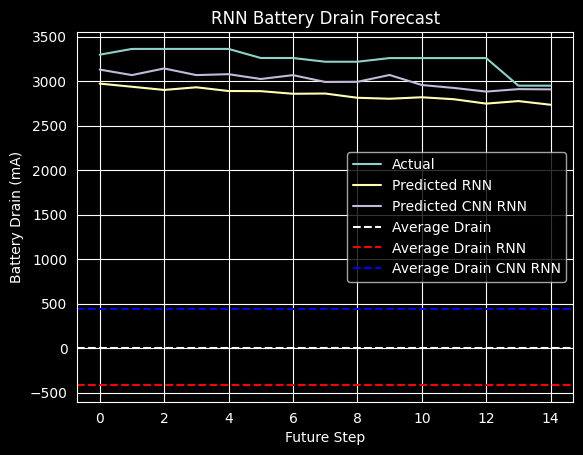

In [14]:
avg_rnn = np.mean(pred_rnn_real)
avg_cnn_rnn = np.mean(pred_cnn_rnn_real)

plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_rnn_real[idx], label="Predicted RNN")
plt.plot(pred_cnn_rnn_real[idx], label="Predicted CNN RNN")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.axhline(avg_rnn, linestyle='--', label="Average Drain RNN", color="red")
plt.axhline(avg_cnn_rnn, linestyle='--', label="Average Drain CNN RNN", color="blue")
plt.title("RNN Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

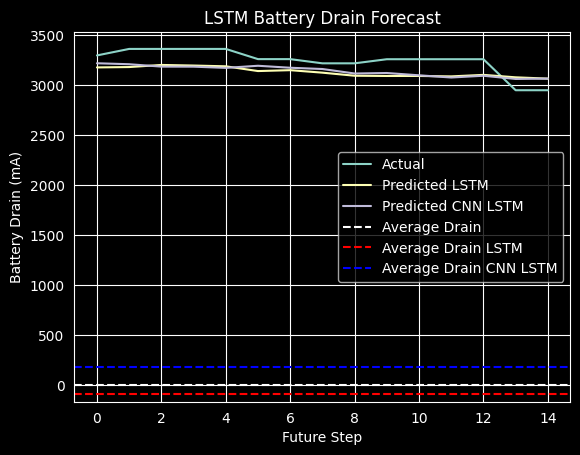

In [15]:
avg_lstm = np.mean(pred_lstm_real)
avg_cnn_lstm = np.mean(pred_cnn_lstm_real)

plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_lstm_real[idx], label="Predicted LSTM")
plt.plot(pred_cnn_lstm_real[idx], label="Predicted CNN LSTM")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.axhline(avg_lstm, linestyle='--', label="Average Drain LSTM", color="red")
plt.axhline(avg_cnn_lstm, linestyle='--', label="Average Drain CNN LSTM", color="blue")
plt.title("LSTM Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

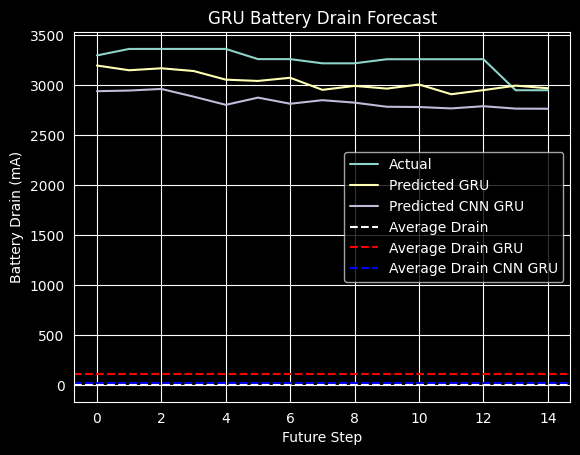

In [16]:
avg_gru = np.mean(pred_gru_real)
avg_cnn_gru = np.mean(pred_cnn_gru_real)

plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_gru_real[idx], label="Predicted GRU")
plt.plot(pred_cnn_gru_real[idx], label="Predicted CNN GRU")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.axhline(avg_gru, linestyle='--', label="Average Drain GRU", color="red")
plt.axhline(avg_cnn_gru, linestyle='--', label="Average Drain CNN GRU", color="blue")
plt.title("GRU Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

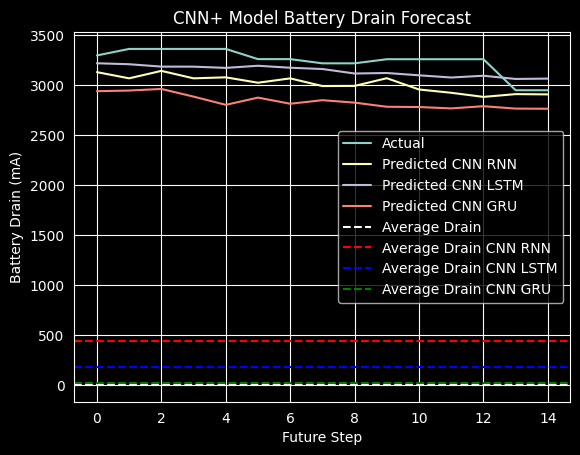

In [17]:
plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_cnn_rnn_real[idx], label="Predicted CNN RNN")
plt.plot(pred_cnn_lstm_real[idx], label="Predicted CNN LSTM")
plt.plot(pred_cnn_gru_real[idx], label="Predicted CNN GRU")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.axhline(avg_cnn_rnn, linestyle='--', label="Average Drain CNN RNN", color="red")
plt.axhline(avg_cnn_lstm, linestyle='--', label="Average Drain CNN LSTM", color="blue")
plt.axhline(avg_cnn_gru, linestyle='--', label="Average Drain CNN GRU", color="green")
plt.title("CNN+ Model Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()